# ECGR 4105 Midterm Project 1

**Group members:** Jordan Mckoy, Miguel Diaz-Alvarez, AJ Carroll

### Import Libaries and Load Data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

### Data Preprocessing

In [3]:
RANDOM_STATE = 42
data = load_breast_cancer()
X, y = data.data, data.target
display(pd.DataFrame(X, columns=data.feature_names).head())
display(pd.DataFrame(y, columns=["target"]).head())

X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,target
0,0
1,0
2,0
3,0
4,0


### Evaluate Model Helper

In [4]:
def evaluate(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(cmap=plt.cm.Blues)
    plt.title(name)
    plt.show()
    print(classification_report(y_test, y_pred, target_names=data.target_names))
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "recall_malignant": recall_score(y_test, y_pred, pos_label=0),
    }

### GridSearch Summarizer

In [5]:
def summarize_grid(grid, name):
    """Print best params and, if the grid searched over scalers, the per-scaler comparison."""
    print(f"{name} — best params: {grid.best_params_}")
    print(f"{name} — best CV score: {grid.best_score_:.4f}")
    cv = pd.DataFrame(grid.cv_results_)
    if "param_scaler" in cv.columns:
        summary = (cv.groupby(cv["param_scaler"].astype(str))["mean_test_score"]
                     .agg(["max", "mean"]).round(4)
                     .sort_values("max", ascending=False))
        display(summary)
    return cv

### Logistic Regression

c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression — best params: {'clf__C': 0.01, 'clf__max_iter': 2000, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'scaler': MinMaxScaler()}
Logistic Regression — best CV score: 1.0000


c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,max,mean
param_scaler,,
MinMaxScaler(),1.0000,0.8326
StandardScaler(),0.9706,0.9187


c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


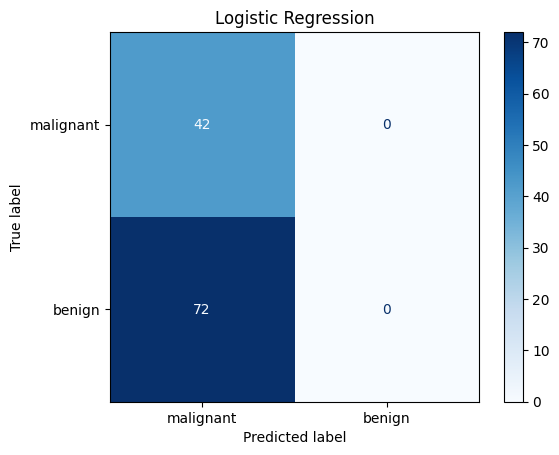

              precision    recall  f1-score   support

   malignant       0.37      1.00      0.54        42
      benign       0.00      0.00      0.00        72

    accuracy                           0.37       114
   macro avg       0.18      0.50      0.27       114
weighted avg       0.14      0.37      0.20       114



c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\antho\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [6]:
log_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(random_state=RANDOM_STATE))]),
    {
        "clf__penalty": ["l2", "l1"],  # liblinear only supports l1/l2
        "clf__C": [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength. C = 1/lambda. Higher C = less regularization.
        "clf__solver": ["liblinear", "saga"],  # saga supports l1/l2 and is faster for large datasets
        "clf__max_iter": [2000, 5000],
        "scaler": [StandardScaler(), MinMaxScaler()],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    # malignant F1 instead of raw malignant recall: recall alone is maximized by
    # predicting everything malignant (heavily regularized L1 does exactly that)
    scoring=make_scorer(recall_score, pos_label=0),
)
log_grid.fit(X_train, y_train)
log_cv = summarize_grid(log_grid, "Logistic Regression")
log_metrics = evaluate(log_grid.best_estimator_, "Logistic Regression")

### Naive Bayes

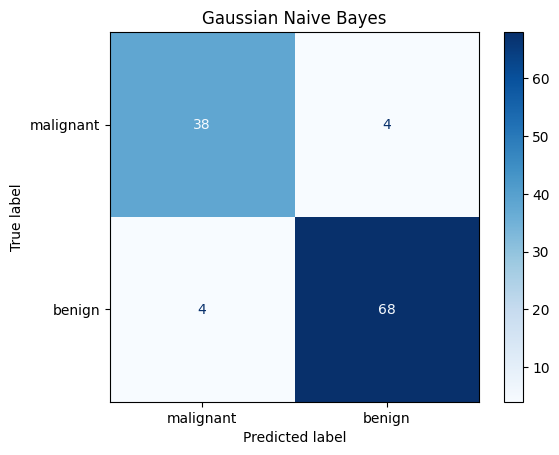

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [7]:
nb_pipe = Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())])
naive_metrics = evaluate(nb_pipe, "Gaussian Naive Bayes")

### Perceptron

Perceptron — best params: {'clf__alpha': 0.0001, 'clf__max_iter': 1000, 'clf__penalty': None, 'scaler': MinMaxScaler()}
Perceptron — best CV score: 0.9824


,max,mean
param_scaler,,
MinMaxScaler(),0.9824,0.9167
StandardScaler(),0.9529,0.9206


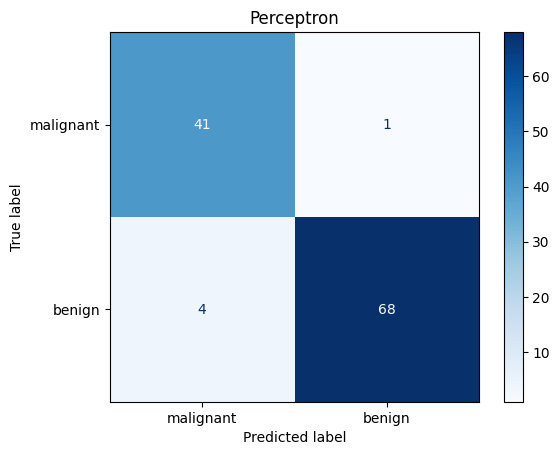

              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [8]:
per_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", Perceptron(random_state=RANDOM_STATE))]),
    {
        "clf__penalty": [None, "l2", "l1", "elasticnet"],
        "clf__alpha": [0.0001, 0.001, 0.01],
        "clf__max_iter": [1000, 2000],
        "scaler": [StandardScaler(), MinMaxScaler()],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(recall_score, pos_label=0),
)
per_grid.fit(X_train, y_train)
per_cv = summarize_grid(per_grid, "Perceptron")
per_metrics = evaluate(per_grid.best_estimator_, "Perceptron")


### Support Vector Machine, SVM

In [9]:
# Name metrics svm_metrics

### Decision Tree Classifier

In [10]:
# Name metrics dt_metrics

### K-Nearest Neighbors, KNN

KNN — best params: {'clf__n_neighbors': 7, 'clf__weights': 'uniform', 'scaler': MinMaxScaler()}
KNN — best CV score: 0.9529


,max,mean
param_scaler,,
MinMaxScaler(),0.9529,0.9451
StandardScaler(),0.9294,0.9235
passthrough,0.9059,0.8853


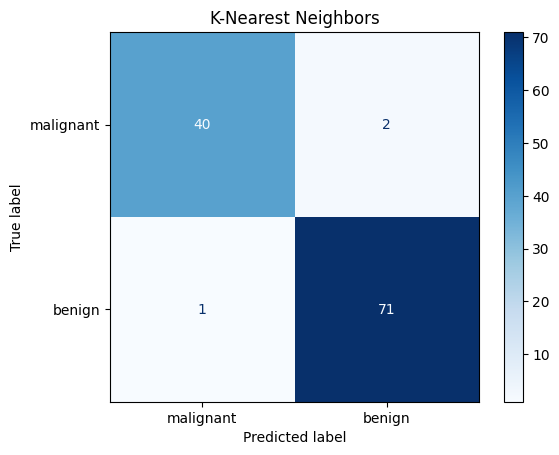

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [11]:
knn_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
    {
        "clf__n_neighbors": [3, 5, 7, 9, 11, 13],
        "clf__weights": ["uniform", "distance"],
        "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(recall_score, pos_label=0),
)
knn_grid.fit(X_train, y_train)
knn_cv = summarize_grid(knn_grid, "KNN")
knn_metrics = evaluate(knn_grid.best_estimator_, "K-Nearest Neighbors")

### Comparison

,accuracy,precision,recall,f1_score,recall_malignant
Logistic Regression,0.3684,0.0000,0.0000,0.0000,1.0000
Naive Bayes,0.9298,0.9444,0.9444,0.9444,0.9048
Perceptron,0.9561,0.9855,0.9444,0.9645,0.9762
KNN,0.9737,0.9726,0.9861,0.9793,0.9524


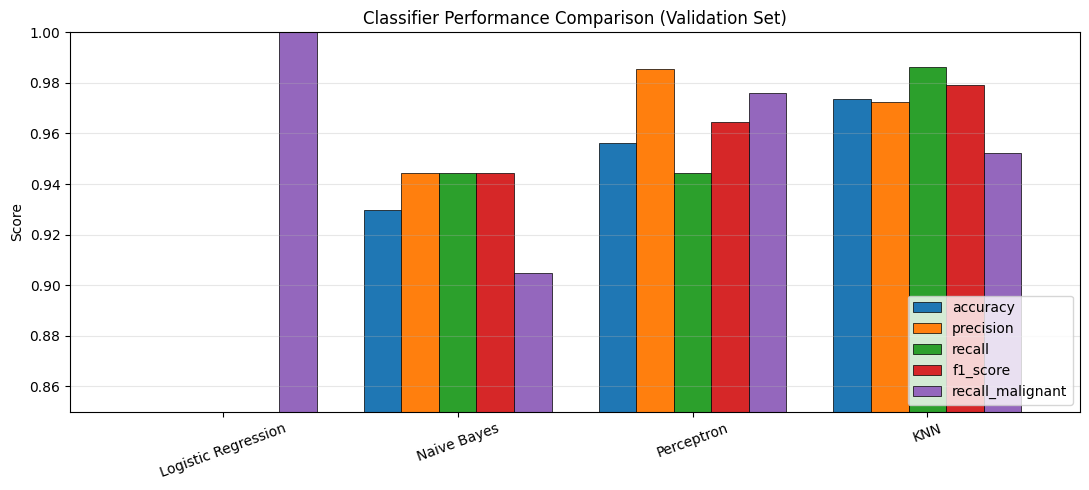

In [12]:
results = pd.DataFrame({
    "Logistic Regression": log_metrics,
    "Naive Bayes": naive_metrics,
    "Perceptron": per_metrics,
    # "SVM": svm_metrics,
    # "Decision Tree": dt_metrics,
    "KNN": knn_metrics,
}).T

display(results.round(4))

ax = results.plot(kind="bar", figsize=(11, 5), rot=20, width=0.8,
                  edgecolor="black", linewidth=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("Score")
ax.set_title("Classifier Performance Comparison (Validation Set)")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()